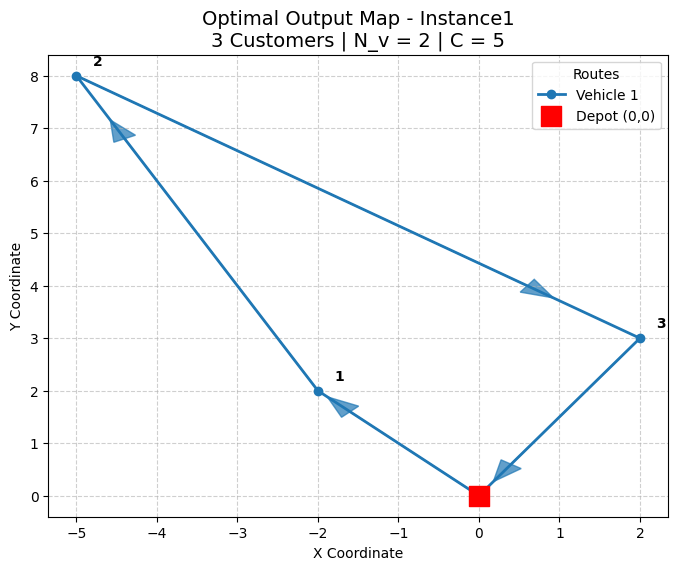

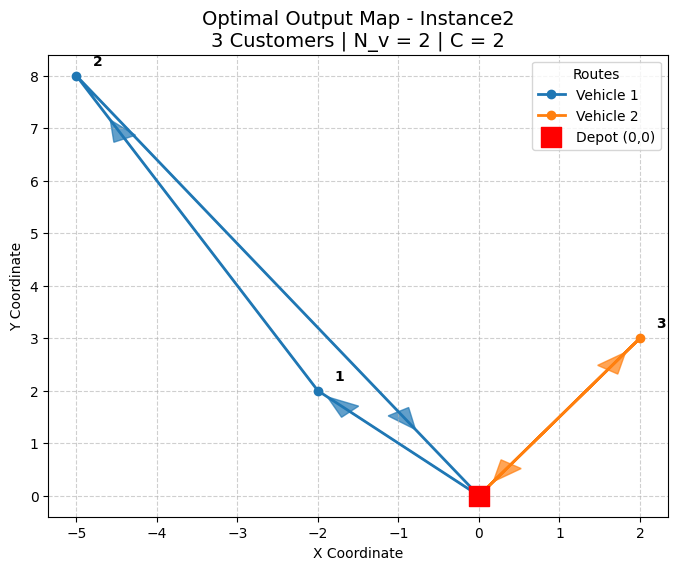

In [5]:
import json
import os
import matplotlib.pyplot as plt
import shutil
import numpy as np

results_dirs = [
    'Results/DQI_Results',
    'Results/Gurobi_Results',
    'Results/QAOA_Results',
    'Results/QITE_Results'
]

routes = {
    'Instance1': [[1, 2, 3]],
    'Instance2': [[1, 2], [3]]
}

# Ensure folders exist
for d in results_dirs:
    os.makedirs(d, exist_ok=True)

with open('final_instances.json', 'r') as f:
    instances = json.load(f)

for inst_key, route_lists in routes.items():
    # Fix the missing mapping matching logic
    inst_num = inst_key.replace("Instance", "")
    target_id = str(inst_num)  # Simply searches for "1" or "2"
    
    config = next(i for i in instances if str(i['instance_id']) == target_id)
    if isinstance(config['customers'][0], dict):
        nodes = [(float(c['x']), float(c['y'])) for c in config['customers']]
    else:
        nodes = [(float(c[0]), float(c[1])) for c in config['customers']]
        
    Nv, C = config['Nv'], config['C']
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Handling matplotlib dynamically
    try: colormap = plt.colormaps['tab10']
    except AttributeError: colormap = plt.cm.get_cmap('tab10')
    
    for idx, r in enumerate(route_lists):
        c_nodes = [0] + r + [0]
        xs = [nodes[n][0] for n in c_nodes]
        ys = [nodes[n][1] for n in c_nodes]
        
        ax.plot(xs, ys, marker='o', markersize=6, linewidth=2, color=colormap(idx%10), label=f'Vehicle {idx+1}')
        
        # Plot Arrows for directionality
        for k in range(len(xs)-1):
            dx, dy = xs[k+1] - xs[k], ys[k+1] - ys[k]
            ax.arrow(xs[k], ys[k], dx*0.8, dy*0.8, head_width=0.3, head_length=0.4, fc=colormap(idx%10), ec=colormap(idx%10), alpha=0.7)
            
    # Draw Depot vs Customers
    ax.scatter([nodes[0][0]], [nodes[0][1]], color='red', s=200, marker='s', zorder=5, label='Depot (0,0)')
    for i in range(1, len(nodes)):
        ax.text(nodes[i][0] + 0.2, nodes[i][1] + 0.2, str(i), fontsize=10, fontweight='bold', zorder=6)
        
    ax.set_title(f"Optimal Output Map - {inst_key}\n{len(nodes)-1} Customers | N_v = {Nv} | C = {C}", fontsize=14)
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(title="Routes", loc='best')
    
    plt.show()  # Prints the image nicely inline into your Notebook view!
    
    # Save the file and copy backwards to all four target folders
    temp_png = f"{inst_key}_Result.png"
    fig.savefig(temp_png, dpi=150, bbox_inches='tight')
    
    for d in results_dirs:
        shutil.copy(temp_png, os.path.join(d, temp_png))
